### Завдання

Маючи вхідний набір даних, розв’зати задачу прогнозування ціни оренди нерухомості та описати свої дії у презентації.

Як розв’язок, так і презентація матимуть 3 основні частини:

Аналіз та підготовка даних.
Моделювання.
Аналіз результатів.



### Чатина 1
Аналіз та підготовка даних.

In [306]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
url = 'https://docs.google.com/spreadsheets/d/1OPnEAT64Patnj_Ifhwn_pM1c15rsBNIoFrtz38A1_W4/edit?gid=881312933#gid=881312933'
url = url[:url.rfind('/')] + '/export?format=csv'
df = pd.read_csv(url)
df

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner
...,...,...,...,...,...,...,...,...,...,...,...,...
4741,2022-05-18,2,15000,1000,3 out of 5,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner
4742,2022-05-15,3,29000,2000,1 out of 4,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner
4743,2022-07-10,3,35000,1750,3 out of 5,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent
4744,2022-07-06,3,45000,1500,23 out of 34,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2,Contact Agent


Інформація про струтруданих

In [307]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


Перевіряєм чи є пусті значення

In [308]:
df.isna().mean()

,0
Posted On,0.0
BHK,0.0
Rent,0.0
Size,0.0
Floor,0.0
Area Type,0.0
Area Locality,0.0
City,0.0
Furnishing Status,0.0
Tenant Preferred,0.0


Аналізуєм які є унікальні занчення для кожного текстового стовпчика крім 'floor'

In [309]:
for col in df.select_dtypes(include = 'object').columns:
  if col == 'Floor':
    continue
  print(f'{col} ({df[col].nunique()}): {df[col].unique()}')

Posted On (81): ['2022-05-18' '2022-05-13' '2022-05-16' '2022-07-04' '2022-05-09'
 '2022-04-29' '2022-06-21' '2022-06-07' '2022-06-20' '2022-05-23'
 '2022-05-14' '2022-05-05' '2022-06-01' '2022-05-17' '2022-06-09'
 '2022-07-02' '2022-06-14' '2022-06-15' '2022-05-28' '2022-05-22'
 '2022-06-18' '2022-06-25' '2022-06-22' '2022-05-21' '2022-06-26'
 '2022-06-16' '2022-06-29' '2022-05-10' '2022-05-12' '2022-06-03'
 '2022-05-31' '2022-06-10' '2022-06-24' '2022-04-30' '2022-05-27'
 '2022-06-06' '2022-05-20' '2022-05-26' '2022-07-03' '2022-04-23'
 '2022-06-19' '2022-07-06' '2022-06-04' '2022-05-30' '2022-06-08'
 '2022-05-03' '2022-05-07' '2022-06-27' '2022-05-15' '2022-04-28'
 '2022-06-28' '2022-06-23' '2022-06-13' '2022-05-04' '2022-04-25'
 '2022-05-06' '2022-06-30' '2022-07-01' '2022-06-17' '2022-06-11'
 '2022-05-11' '2022-06-12' '2022-06-05' '2022-05-25' '2022-05-24'
 '2022-05-19' '2022-04-24' '2022-04-27' '2022-05-08' '2022-04-26'
 '2022-06-02' '2022-05-29' '2022-07-07' '2022-07-08' '2022-0

In [310]:
df.shape

(4746, 12)

перйменовуєм стовпці для зручності в роботі

In [311]:
df = df.rename(columns={
    'Posted On': 'post_date',
    'BHK': 'bhk',
    'Rent': 'rent',
    'Size': 'size',
    'Floor': 'floor',
    'Area Type': 'area_type',
    'Area Locality': 'locality',
    'City': 'city',
    'Furnishing Status': 'furnish',
    'Tenant Preferred': 'tenant',
    'Bathroom': 'bath',
    'Point of Contact': 'contact',
})
df

,post_date,bhk,rent,size,floor,area_type,locality,city,furnish,tenant,bath,contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner
...,...,...,...,...,...,...,...,...,...,...,...,...
4741,2022-05-18,2,15000,1000,3 out of 5,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner
4742,2022-05-15,3,29000,2000,1 out of 4,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner
4743,2022-07-10,3,35000,1750,3 out of 5,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent
4744,2022-07-06,3,45000,1500,23 out of 34,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2,Contact Agent


морматуємо дату та виводимо додатково стовпець місяць

In [312]:
df['post_date'] = pd.to_datetime(df['post_date'])
df['month'] = df['post_date'].apply(lambda x: x.month)
for old, new in {'Ground': '0', 'Upper': '-1', 'Lower': '-2'}.items():
    df.floor = df.floor.str.replace(old, new)
df

,post_date,bhk,rent,size,floor,area_type,locality,city,furnish,tenant,bath,contact,month
0,2022-05-18,2,10000,1100,0 out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,5
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,5
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,5
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,7
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4741,2022-05-18,2,15000,1000,3 out of 5,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner,5
4742,2022-05-15,3,29000,2000,1 out of 4,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner,5
4743,2022-07-10,3,35000,1750,3 out of 5,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent,7
4744,2022-07-06,3,45000,1500,23 out of 34,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2,Contact Agent,7


In [313]:

df['max_floor'] = df.floor.apply(lambda x: int(x.split(' ')[-1]))
df['floor_'] = df.floor.apply(lambda x: int(x.split(' ')[0]))

df['floor'].size


4746

In [314]:
df['floor'].isna().mean()

np.float64(0.0)

In [315]:
df['floor_'].size


4746

In [316]:
df['floor_'].isna().mean()

np.float64(0.0)

In [317]:
df['floor'].nunique()

480

In [318]:
df['floor_'].unique()

array([ 0,  1,  2,  4,  3,  5,  7,  8, -1, 11, -2,  6, 14, 43, 13, 18, 17,
        9, 19, 60, 34, 12, 26, 25, 53, 16, 10, 39, 32, 47, 28, 20, 15, 65,
       40, 37, 22, 21, 30, 35, 33, 44, 41, 46, 27, 45, 48, 50, 24, 23, 29,
       49, 36, 76])

In [319]:
df['max_floor'].size

4746

In [320]:
df['max_floor'].isna().mean()

np.float64(0.0)

In [321]:
df['max_floor'].nunique()

67

In [322]:
df['max_floor'].unique()

array([ 2,  3,  1,  4,  5, 14,  8,  6, 19, 10,  7, 13, 78, 18, 12, 24, 31,
       21, 23, 20,  9, 22, 58, 16, 66, 48, 40, 44, 42, 41, 60, 32, 30, 29,
       89, 15, 11, 28, 17, 45, 35, 75, 38, 51, 43, 25, 27, 26, 76, 36, 37,
       55, 68, 77, 50, 59, 62, 39, 52, 54, 33, 46, 85, 71, 81, 34,  0])

в яких рядках були не вказано перх будинку

In [323]:
df[df[['floor_', 'max_floor']].isna().any(axis=1)]

,post_date,bhk,rent,size,floor,area_type,locality,city,furnish,tenant,bath,contact,month,max_floor,floor_


In [324]:
df.drop(columns=['post_date','floor'],errors='ignore', inplace= True)


In [325]:
df

,bhk,rent,size,area_type,locality,city,furnish,tenant,bath,contact,month,max_floor,floor_
0,2,10000,1100,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,5,2,0
1,2,20000,800,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,5,3,1
2,2,17000,1000,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,5,3,1
3,2,10000,800,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,7,2,1
4,2,7500,850,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner,5,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4741,2,15000,1000,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner,5,5,3
4742,3,29000,2000,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner,5,4,1
4743,3,35000,1750,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent,7,5,3
4744,3,45000,1500,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2,Contact Agent,7,34,23


In [326]:
df.area_type.value_counts() ,df.locality.value_counts() ,df.city.value_counts() ,df.furnish.value_counts() ,df.tenant.value_counts(),df.bath.value_counts() ,df.contact.value_counts()

(area_type
 Super Area     2446
 Carpet Area    2298
 Built Area        2
 Name: count, dtype: int64,
 locality
 Bandra West                       37
 Gachibowli                        29
 Electronic City                   24
 Miyapur, NH 9                     22
 Velachery                         22
                                   ..
 Hoysala Nagar                      1
 Nagarabhavi                        1
 Shamanna Garden, Wilson Garden     1
 Jagadish Nagar, Kaggadasapura      1
 Purba Sinthi Area                  1
 Name: count, Length: 2235, dtype: int64,
 city
 Mumbai       972
 Chennai      891
 Bangalore    886
 Hyderabad    868
 Delhi        605
 Kolkata      524
 Name: count, dtype: int64,
 furnish
 Semi-Furnished    2251
 Unfurnished       1815
 Furnished          680
 Name: count, dtype: int64,
 tenant
 Bachelors/Family    3444
 Bachelors            830
 Family               472
 Name: count, dtype: int64,
 bath
 2     2291
 1     1474
 3      749
 4      156
 5       

In [327]:
df.describe()

,bhk,rent,size,bath,month,max_floor,floor_
count,4746.000000,4.746000e+03,4746.000000,4746.000000,4746.000000,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866,5.755794,6.968605,3.436157
std,0.832256,7.810641e+04,634.202328,0.884532,0.832426,9.467245,5.773950
min,1.000000,1.200000e+03,10.000000,1.000000,4.000000,0.000000,-2.000000
25%,2.000000,1.000000e+04,550.000000,1.000000,5.000000,2.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000,6.000000,4.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000,6.000000,6.000000,3.000000
max,6.000000,3.500000e+06,8000.000000,10.000000,7.000000,89.000000,76.000000


Прибираєш шуми


In [328]:
df = df.loc[~df['area_type'].astype(str).str.replace('\u00a0',' ', regex=False).str.strip().str.casefold().eq('built area')].copy()
df = df.loc[~df['contact'].astype(str).str.replace('\u00a0',' ', regex=False).str.strip().str.casefold().eq('contact builder')].copy()




In [329]:
df.area_type.value_counts() ,df.locality.value_counts() ,df.city.value_counts() ,df.furnish.value_counts() ,df.tenant.value_counts(),df.bath.value_counts() ,df.contact.value_counts()

(area_type
 Super Area     2445
 Carpet Area    2298
 Name: count, dtype: int64,
 locality
 Bandra West                              37
 Gachibowli                               29
 Electronic City                          24
 Velachery                                22
 Miyapur, NH 9                            22
                                          ..
 Kakatiya Hills Madhapur                   1
 sanath nagar Ashok colony                 1
 Mokila                                    1
 Neknampur, Manikonda, Outer Ring Road     1
 Naseeb Nagar, Hyderabad                   1
 Name: count, Length: 2234, dtype: int64,
 city
 Mumbai       972
 Chennai      890
 Bangalore    886
 Hyderabad    866
 Delhi        605
 Kolkata      524
 Name: count, dtype: int64,
 furnish
 Semi-Furnished    2251
 Unfurnished       1813
 Furnished          679
 Name: count, dtype: int64,
 tenant
 Bachelors/Family    3441
 Bachelors            830
 Family               472
 Name: count, dtype: int64,
 bath
 

In [330]:
s = (df['tenant'].astype(str)
                 .str.replace('\u00a0', ' ', regex=False)
                 .str.strip()
                 .str.casefold())

df['is_family']    = s.str.contains(r'\bfamily\b').astype(int)
df['is_bachelors'] = s.str.contains(r'\bbachelors?\b').astype(int)

df


,bhk,rent,size,area_type,locality,city,furnish,tenant,bath,contact,month,max_floor,floor_,is_family,is_bachelors
0,2,10000,1100,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner,5,2,0,1,1
1,2,20000,800,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,5,3,1,1,1
2,2,17000,1000,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner,5,3,1,1,1
3,2,10000,800,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,7,2,1,1,1
4,2,7500,850,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner,5,2,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4741,2,15000,1000,Carpet Area,Bandam Kommu,Hyderabad,Semi-Furnished,Bachelors/Family,2,Contact Owner,5,5,3,1,1
4742,3,29000,2000,Super Area,"Manikonda, Hyderabad",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Owner,5,4,1,1,1
4743,3,35000,1750,Carpet Area,"Himayath Nagar, NH 7",Hyderabad,Semi-Furnished,Bachelors/Family,3,Contact Agent,7,5,3,1,1
4744,3,45000,1500,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2,Contact Agent,7,34,23,1,0


Нормалізуєм текст та трансформуємо дані в бінарні

In [331]:
df[['contact','furnish','locality']] = df[['contact','furnish','locality']].apply(lambda s: s.astype(str).str.lower().str.strip().str.replace(r'\s+',' ', regex=True))
s = df['contact'].astype(str)  # вже нижній регістр і trim з кроку 1
df['contact_role'] = np.select([s.str.contains('owner'), s.str.contains('agent|broker'), s.str.contains('builder')], ['owner','agent','builder'], default='unknown')
role_cols = ['contact_owner','contact_agent','contact_builder','contact_unknown']
role_dum  = pd.get_dummies(df['contact_role'], prefix='contact', dtype='int8').reindex(columns=role_cols, fill_value=0)
df = pd.concat([df, role_dum], axis=1)
furn_cols = ['furnish_furnished','furnish_semi-furnished','furnish_unfurnished']
furn_dum  = pd.get_dummies(df['furnish'], prefix='furnish', dtype='int8').reindex(columns=furn_cols, fill_value=0)
df = pd.concat([df, furn_dum], axis=1)

df

,bhk,rent,size,area_type,locality,city,furnish,tenant,bath,contact,...,is_family,is_bachelors,contact_role,contact_owner,contact_agent,contact_builder,contact_unknown,furnish_furnished,furnish_semi-furnished,furnish_unfurnished
0,2,10000,1100,Super Area,bandel,Kolkata,unfurnished,Bachelors/Family,2,contact owner,...,1,1,owner,1,0,0,0,0,0,1
1,2,20000,800,Super Area,"phool bagan, kankurgachi",Kolkata,semi-furnished,Bachelors/Family,1,contact owner,...,1,1,owner,1,0,0,0,0,1,0
2,2,17000,1000,Super Area,salt lake city sector 2,Kolkata,semi-furnished,Bachelors/Family,1,contact owner,...,1,1,owner,1,0,0,0,0,1,0
3,2,10000,800,Super Area,dumdum park,Kolkata,unfurnished,Bachelors/Family,1,contact owner,...,1,1,owner,1,0,0,0,0,0,1
4,2,7500,850,Carpet Area,south dum dum,Kolkata,unfurnished,Bachelors,1,contact owner,...,0,1,owner,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4741,2,15000,1000,Carpet Area,bandam kommu,Hyderabad,semi-furnished,Bachelors/Family,2,contact owner,...,1,1,owner,1,0,0,0,0,1,0
4742,3,29000,2000,Super Area,"manikonda, hyderabad",Hyderabad,semi-furnished,Bachelors/Family,3,contact owner,...,1,1,owner,1,0,0,0,0,1,0
4743,3,35000,1750,Carpet Area,"himayath nagar, nh 7",Hyderabad,semi-furnished,Bachelors/Family,3,contact agent,...,1,1,agent,0,1,0,0,0,1,0
4744,3,45000,1500,Carpet Area,gachibowli,Hyderabad,semi-furnished,Family,2,contact agent,...,1,0,agent,0,1,0,0,0,1,0


In [332]:
df['rent_per_sqft'] = df['rent'] / df['size'].replace(0, np.nan)
df

,bhk,rent,size,area_type,locality,city,furnish,tenant,bath,contact,...,is_bachelors,contact_role,contact_owner,contact_agent,contact_builder,contact_unknown,furnish_furnished,furnish_semi-furnished,furnish_unfurnished,rent_per_sqft
0,2,10000,1100,Super Area,bandel,Kolkata,unfurnished,Bachelors/Family,2,contact owner,...,1,owner,1,0,0,0,0,0,1,9.090909
1,2,20000,800,Super Area,"phool bagan, kankurgachi",Kolkata,semi-furnished,Bachelors/Family,1,contact owner,...,1,owner,1,0,0,0,0,1,0,25.000000
2,2,17000,1000,Super Area,salt lake city sector 2,Kolkata,semi-furnished,Bachelors/Family,1,contact owner,...,1,owner,1,0,0,0,0,1,0,17.000000
3,2,10000,800,Super Area,dumdum park,Kolkata,unfurnished,Bachelors/Family,1,contact owner,...,1,owner,1,0,0,0,0,0,1,12.500000
4,2,7500,850,Carpet Area,south dum dum,Kolkata,unfurnished,Bachelors,1,contact owner,...,1,owner,1,0,0,0,0,0,1,8.823529
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4741,2,15000,1000,Carpet Area,bandam kommu,Hyderabad,semi-furnished,Bachelors/Family,2,contact owner,...,1,owner,1,0,0,0,0,1,0,15.000000
4742,3,29000,2000,Super Area,"manikonda, hyderabad",Hyderabad,semi-furnished,Bachelors/Family,3,contact owner,...,1,owner,1,0,0,0,0,1,0,14.500000
4743,3,35000,1750,Carpet Area,"himayath nagar, nh 7",Hyderabad,semi-furnished,Bachelors/Family,3,contact agent,...,1,agent,0,1,0,0,0,1,0,20.000000
4744,3,45000,1500,Carpet Area,gachibowli,Hyderabad,semi-furnished,Family,2,contact agent,...,0,agent,0,1,0,0,0,1,0,30.000000


In [333]:
df_all = df.copy()

In [334]:
num_feats = ['size','bhk','bath','floor_','max_floor']  # тільки числові базові
corr_pearson  = df_all[num_feats + ['rent_per_sqft']].corr(numeric_only=True)['rent_per_sqft'].drop('rent_per_sqft').sort_values(ascending=False)
corr_spearman = df_all[num_feats + ['rent_per_sqft']].corr(method='spearman', numeric_only=True)['rent_per_sqft'].drop('rent_per_sqft').sort_values(ascending=False)
corr_pearson, corr_spearman


(max_floor    0.268857
 floor_       0.254092
 bath         0.195391
 bhk          0.137479
 size        -0.078878
 Name: rent_per_sqft, dtype: float64,
 max_floor    0.520118
 floor_       0.434618
 bath         0.204525
 bhk          0.096140
 size        -0.176631
 Name: rent_per_sqft, dtype: float64)

In [335]:
df_all.groupby('contact_role')['rent_per_sqft'].median().sort_values(ascending=False)
df_all.groupby('furnish')['rent_per_sqft'].median().sort_values(ascending=False)
df_all.groupby(['is_family','is_bachelors'])['rent_per_sqft'].median().sort_values(ascending=False)


is_family  is_bachelors
0          1               24.000000
1          0               23.508772
           1               18.571429
Name: rent_per_sqft, dtype: float64

In [336]:
df[['rent_per_sqft','size','bhk','bath','floor_','max_floor']].describe()


,rent_per_sqft,size,bhk,bath,floor_,max_floor
count,4743.000000,4743.000000,4743.000000,4743.000000,4743.000000,4743.000000
mean,39.273326,967.702087,2.084335,1.966266,3.436854,6.971115
std,59.870668,634.312842,0.832220,0.884589,5.775514,9.469646
min,0.571429,10.000000,1.000000,1.000000,-2.000000,0.000000
25%,13.333333,550.000000,2.000000,1.000000,1.000000,2.000000
50%,20.000000,850.000000,2.000000,2.000000,2.000000,4.000000
75%,42.056622,1200.000000,3.000000,2.000000,3.000000,6.000000
max,1500.000000,8000.000000,6.000000,10.000000,76.000000,89.000000


<Axes: ylabel='Frequency'>

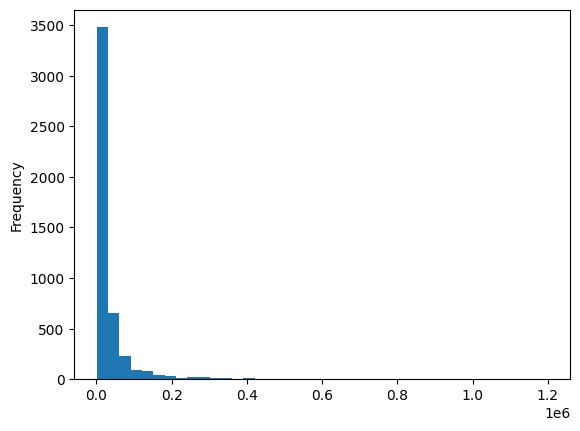

In [337]:
q_hi = df['rent_per_sqft'].quantile(0.99)
df.loc[df['rent_per_sqft'] <= q_hi, 'rent'].plot(kind='hist', bins=40)


<Axes: >

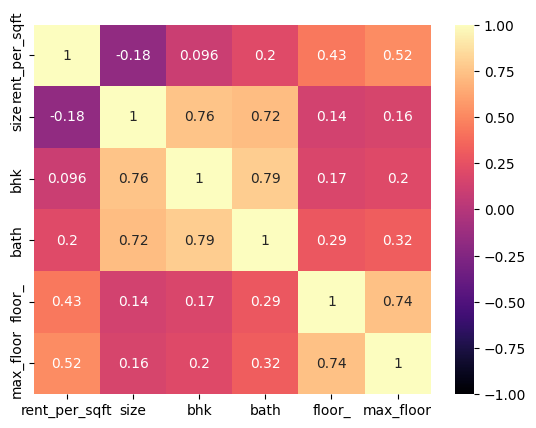

In [338]:
num_feats = ['rent_per_sqft','size','bhk','bath','floor_','max_floor']
corr = df[num_feats].corr(method='spearman', numeric_only=True)
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap='magma')


Порівняння: кореляції з rent_per_sqft vs з rent (і log1p(rent))

In [339]:
num_feats = ['size','bhk','bath','floor_','max_floor']

corr_rps  = df[['rent_per_sqft'] + num_feats].corr(method='spearman', numeric_only=True)['rent_per_sqft'].drop('rent_per_sqft')
corr_rent = df[['rent']          + num_feats].corr(method='spearman', numeric_only=True)['rent'].drop('rent')
corr_logr = df.assign(log_rent=np.log1p(df['rent']))[['log_rent'] + num_feats].corr(method='spearman', numeric_only=True)['log_rent'].drop('log_rent')

pd.DataFrame({'rent_per_sqft': corr_rps, 'rent': corr_rent, 'log_rent': corr_logr}).sort_values('rent_per_sqft', ascending=False)


,rent_per_sqft,rent,log_rent
max_floor,0.520118,0.581873,0.581873
floor_,0.434618,0.483835,0.483835
bath,0.204525,0.662711,0.662711
bhk,0.096140,0.568042,0.568042
size,-0.176631,0.521096,0.521096


Короткі висновки про це етап даних
rent — сильно скошений праворуч rent_per_sqft (менша гетероскедастичність).

За Spearman для rent_per_sqft:
max_floor, floor_ — помітна позитивна залежність; bath > bhk; size — слабка негативна (типовий ефект: великі квартири дешевші за м²).

За орендарями: у твоїх зрізах bachelors-only дорожчі за м², both — найдешевші.

Отже для моделей:

Лінійна: краще вчитись на rent_per_sqft, а прогноз множити на size → отримаємо rent.

Дерев’яна: вчитись напряму на rent (уловить нелінійності/взаємодії).

Підготуємо фрейм загальний

In [340]:
contact_cols = [c for c in df.columns if c.startswith('contact_') and c != 'contact_role']
furnish_cols = [c for c in df.columns if c.startswith('furnish_')]

core_nums = ['size','bhk','bath','floor_','max_floor','pct_floor','is_ground','is_top','is_family','is_bachelors']
core_nums = [c for c in core_nums if c in df.columns]

if 'rent_per_sqft' not in df.columns and {'rent','size'}.issubset(df.columns):
    df['rent_per_sqft'] = df['rent'] / df['size'].replace(0, np.nan)

keep_cols = ['rent'] + (['rent_per_sqft'] if 'rent_per_sqft' in df.columns else []) + core_nums + contact_cols + furnish_cols
df_gen = df[keep_cols].copy()
print('✅ df_gen:', df_gen.shape)
df_gen

✅ df_gen: (4743, 16)


,rent,rent_per_sqft,size,bhk,bath,floor_,max_floor,is_family,is_bachelors,contact_owner,contact_agent,contact_builder,contact_unknown,furnish_furnished,furnish_semi-furnished,furnish_unfurnished
0,10000,9.090909,1100,2,2,0,2,1,1,1,0,0,0,0,0,1
1,20000,25.000000,800,2,1,1,3,1,1,1,0,0,0,0,1,0
2,17000,17.000000,1000,2,1,1,3,1,1,1,0,0,0,0,1,0
3,10000,12.500000,800,2,1,1,2,1,1,1,0,0,0,0,0,1
4,7500,8.823529,850,2,1,1,2,0,1,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4741,15000,15.000000,1000,2,2,3,5,1,1,1,0,0,0,0,1,0
4742,29000,14.500000,2000,3,3,1,4,1,1,1,0,0,0,0,1,0
4743,35000,20.000000,1750,3,3,3,5,1,1,0,1,0,0,0,1,0
4744,45000,30.000000,1500,3,2,23,34,1,0,0,1,0,0,0,1,0


готуєм з розбивкою на місцях

In [341]:
city_s = df.loc[df_gen.index, 'city'].astype(str)

city_counts = city_s.value_counts()
city_counts


,count
city,
Mumbai,972
Chennai,890
Bangalore,886
Hyderabad,866
Delhi,605
Kolkata,524


In [342]:
city_s = df.loc[df_gen.index, 'city'].astype(str)

cities = city_s.unique().tolist()
city_frames = {c: df_gen.loc[city_s == c].copy() for c in cities}
{k: v.shape for k, v in city_frames.items()}


{'Kolkata': (524, 16),
 'Mumbai': (972, 16),
 'Bangalore': (886, 16),
 'Delhi': (605, 16),
 'Chennai': (890, 16),
 'Hyderabad': (866, 16)}

In [343]:
def prepare_city_frame(dfg: pd.DataFrame) -> pd.DataFrame:

    bool_cols = dfg.select_dtypes(include='bool').columns
    if len(bool_cols):
        dfg[bool_cols] = dfg[bool_cols].astype('int8')

    const_cols = [c for c in dfg.columns if c not in ('rent','rent_per_sqft') and dfg[c].nunique(dropna=False) <= 1]
    if const_cols:
        dfg = dfg.drop(columns=const_cols)
    return dfg

city_frames = {c: prepare_city_frame(df_gen.loc[city_s == c].copy()) for c in city_counts.index}
{k: v.shape for k, v in city_frames.items()}


{'Mumbai': (972, 14),
 'Chennai': (890, 14),
 'Bangalore': (886, 14),
 'Hyderabad': (866, 14),
 'Delhi': (605, 14),
 'Kolkata': (524, 14)}

In [344]:
# Виберемо одну міську таблицю, щоб зчитати наявні числові колонки
any_city_df = next(iter(city_frames.values()))


feat_base = [c for c in any_city_df.columns
             if c not in ['rent', 'rent_per_sqft']
             and pd.api.types.is_numeric_dtype(any_city_df[c])]

feat_linear = feat_base.copy()
feat_tree   = feat_base.copy()

print('feat_linear:', feat_linear)
print('feat_tree  :', feat_tree)

X_lin_city, y_lin_city = {}, {}
X_rf_city,  y_rf_city  = {}, {}

for c, dfg in city_frames.items():
    cols_lin = [col for col in feat_linear if col in dfg.columns]
    cols_rf  = [col for col in feat_tree   if col in dfg.columns]

    X_lin_city[c] = dfg[cols_lin].fillna(0)
    y_lin_city[c] = dfg['rent_per_sqft'].astype(float)

    X_rf_city[c]  = dfg[cols_rf].fillna(0)
    y_rf_city[c]  = dfg['rent'].astype(float)


{c: (X_lin_city[c].shape, X_rf_city[c].shape) for c in city_frames.keys()}


feat_linear: ['size', 'bhk', 'bath', 'floor_', 'max_floor', 'is_family', 'is_bachelors', 'contact_owner', 'contact_agent', 'furnish_furnished', 'furnish_semi-furnished', 'furnish_unfurnished']
feat_tree  : ['size', 'bhk', 'bath', 'floor_', 'max_floor', 'is_family', 'is_bachelors', 'contact_owner', 'contact_agent', 'furnish_furnished', 'furnish_semi-furnished', 'furnish_unfurnished']


{'Mumbai': ((972, 12), (972, 12)),
 'Chennai': ((890, 12), (890, 12)),
 'Bangalore': ((886, 12), (886, 12)),
 'Hyderabad': ((866, 12), (866, 12)),
 'Delhi': ((605, 12), (605, 12)),
 'Kolkata': ((524, 12), (524, 12))}

In [345]:
{c: city_frames[c].shape for c in city_frames}

city_frames['Chennai'].head(10)


,rent,rent_per_sqft,size,bhk,bath,floor_,max_floor,is_family,is_bachelors,contact_owner,contact_agent,furnish_furnished,furnish_semi-furnished,furnish_unfurnished
2987,15000,13.636364,1100,2,2,1,2,0,1,1,0,0,1,0
2988,6500,6.500000,1000,2,2,0,1,1,1,1,0,0,1,0
2989,90000,37.500000,2400,3,3,1,3,1,1,0,1,0,1,0
2990,200000,66.666667,3000,3,4,1,1,1,0,0,1,1,0,0
2991,15000,23.076923,650,1,1,0,2,1,1,1,0,0,1,0
2992,15000,15.000000,1000,2,2,17,31,0,1,1,0,0,1,0
2993,7600,10.857143,700,2,2,1,3,1,1,1,0,0,0,1
2994,29000,24.166667,1200,3,3,1,3,0,1,0,1,0,1,0
2995,20000,11.695906,1710,3,3,15,29,1,1,1,0,0,1,0
2996,12000,20.000000,600,2,2,1,3,1,1,1,0,1,0,0


In [346]:
def city_corr_full(city, target='rent_per_sqft', method='spearman'):
    dfg = city_frames[city].select_dtypes('number')
    s = dfg.corr(method=method)[target].drop(target)
    return s.sort_values(ascending=False)

city_corr_full('Mumbai')



,rent_per_sqft
rent,0.809051
size,0.413530
bath,0.397167
bhk,0.396306
contact_agent,0.386123
max_floor,0.256327
floor_,0.245139
furnish_furnished,0.220295
furnish_semi-furnished,0.096536
is_bachelors,0.062913


In [347]:
common_feats = None
for c, dfg in city_frames.items():
    num = set(dfg.select_dtypes('number').columns)
    common_feats = num if common_feats is None else (common_feats & num)
common_feats -= {'rent','rent_per_sqft'}
common_feats = sorted(common_feats)

def corr_matrix_by_city(cities=None, features=None, target='rent_per_sqft', method='spearman'):
    if cities is None:
        cities = list(city_frames.keys())
    if features is None:
        features = common_feats
    data = {}
    for city in cities:
        dfg = city_frames[city][[target] + features]
        data[city] = dfg.corr(method=method)[target].drop(target)
    return pd.DataFrame(data).loc[features]

corr_all = corr_matrix_by_city()
corr_all.round(3)


,Mumbai,Chennai,Bangalore,Hyderabad,Delhi,Kolkata
bath,0.397,0.188,0.176,0.078,0.129,0.121
bhk,0.396,0.211,0.152,0.091,0.059,-0.060
contact_agent,0.386,0.446,0.445,0.324,0.025,0.313
contact_owner,-0.386,-0.446,-0.445,-0.324,-0.025,-0.313
floor_,0.245,0.188,0.295,0.207,0.013,0.016
furnish_furnished,0.220,0.134,0.116,0.110,0.155,0.136
furnish_semi-furnished,0.097,0.084,0.014,0.049,-0.034,0.007
furnish_unfurnished,-0.299,-0.163,-0.098,-0.125,-0.083,-0.096
is_bachelors,0.063,-0.000,-0.013,-0.055,0.072,0.042
is_family,-0.011,-0.153,-0.127,-0.064,-0.009,-0.092


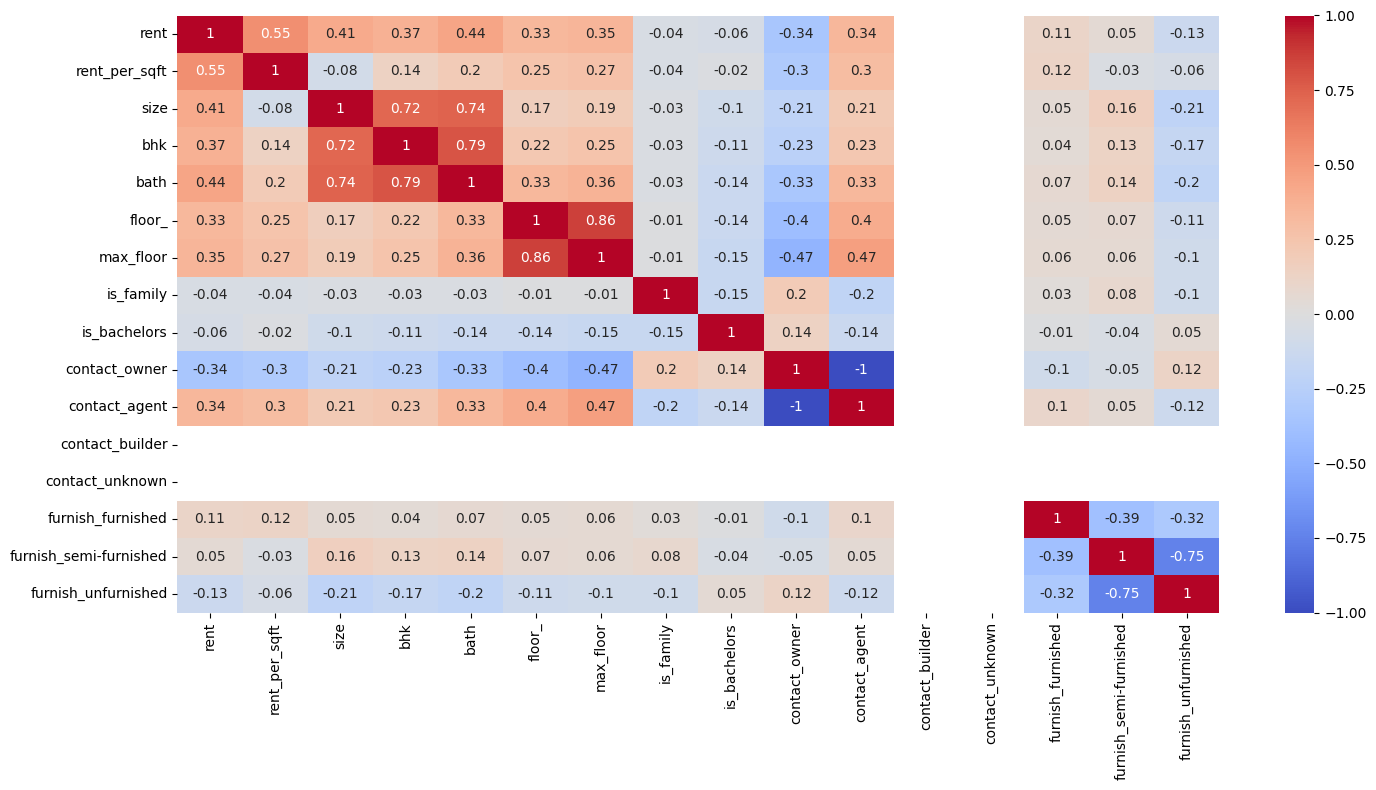

In [348]:


corr = df_gen.select_dtypes('number').corr(method='pearson').round(2)
fig, ax = plt.subplots(figsize=(15, 8))
sns.heatmap(corr, annot=True, ax=ax, cmap='coolwarm', vmin=-1, vmax=1, center=0)
fig.tight_layout()


In [349]:
city_dum = pd.get_dummies(
    df.loc[df_gen.index, 'city'].astype(str).str.strip(),
    prefix='city', dtype='uint8'
)

df_gen = pd.concat([df_gen, city_dum], axis=1)

print('df_gen:', df_gen.shape)
df_gen.filter(like='city_').head()

df_gen: (4743, 22)


,city_Bangalore,city_Chennai,city_Delhi,city_Hyderabad,city_Kolkata,city_Mumbai
0,0,0,0,0,1,0
1,0,0,0,0,1,0
2,0,0,0,0,1,0
3,0,0,0,0,1,0
4,0,0,0,0,1,0


In [350]:

bool_cols = df_gen.select_dtypes('bool').columns
df_gen[bool_cols] = df_gen[bool_cols].astype('uint8')

num = df_gen.select_dtypes('number')
num = num.loc[:, num.nunique() > 1]


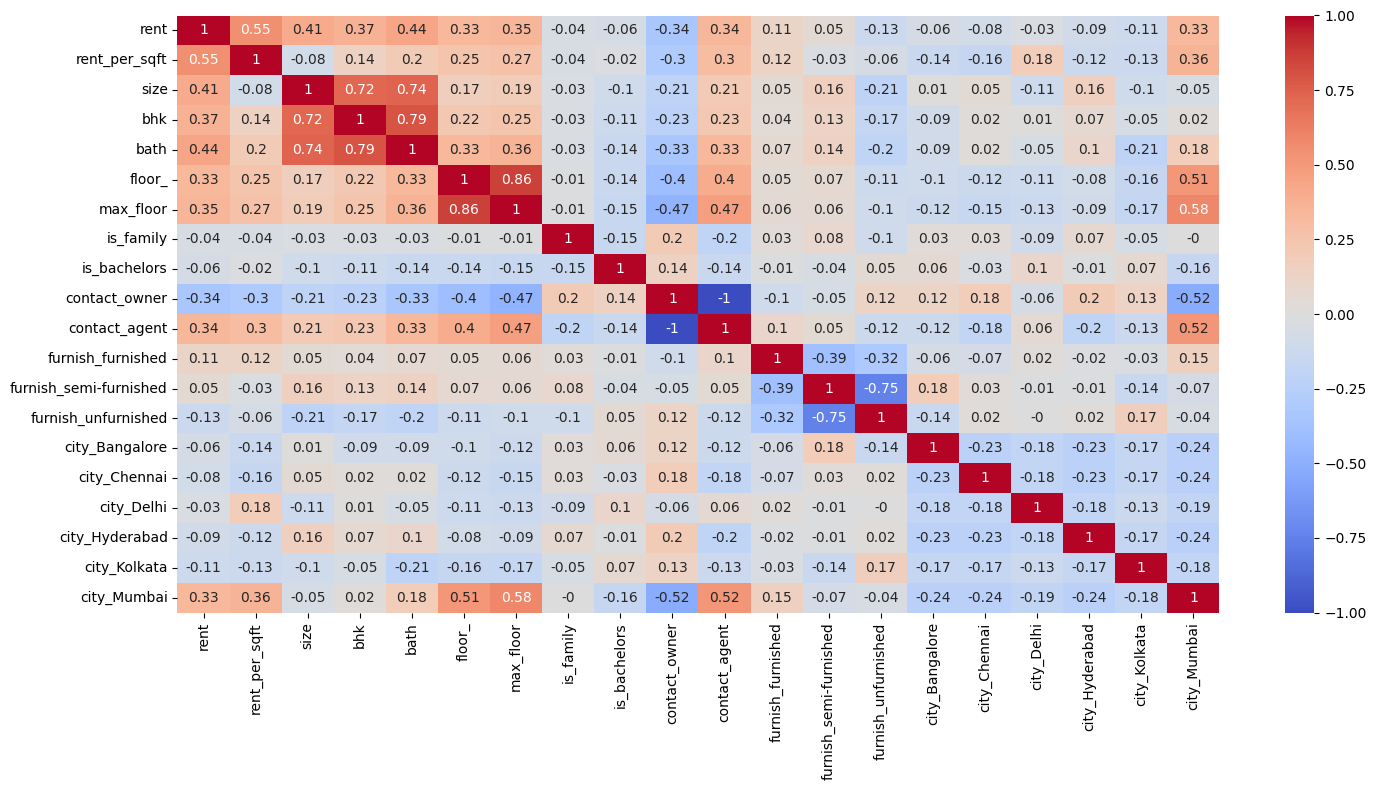

In [351]:
fig, ax = plt.subplots(figsize=(15, 8))
sns.heatmap(num.corr(method='pearson').round(2), annot=True,
            cmap='coolwarm', vmin=-1, vmax=1, center=0, ax=ax)
fig.tight_layout()


In [352]:
df_gen.describe()

,rent,rent_per_sqft,size,bhk,bath,floor_,max_floor,is_family,is_bachelors,contact_owner,...,contact_unknown,furnish_furnished,furnish_semi-furnished,furnish_unfurnished,city_Bangalore,city_Chennai,city_Delhi,city_Hyderabad,city_Kolkata,city_Mumbai
count,4.743000e+03,4743.000000,4743.000000,4743.000000,4743.000000,4743.000000,4743.000000,4743.000000,4743.000000,4743.000000,...,4743.0,4743.000000,4743.000000,4743.000000,4743.000000,4743.000000,4743.000000,4743.000000,4743.000000,4743.000000
mean,3.501000e+04,39.273326,967.702087,2.084335,1.966266,3.436854,6.971115,0.825005,0.900485,0.677630,...,0.0,0.143158,0.474594,0.382248,0.186802,0.187645,0.127556,0.182585,0.110479,0.204934
std,7.812827e+04,59.870668,634.312842,0.832220,0.884589,5.775514,9.469646,0.380003,0.299384,0.467433,...,0.0,0.350271,0.499407,0.485988,0.389793,0.390470,0.333630,0.386367,0.313518,0.403696
min,1.200000e+03,0.571429,10.000000,1.000000,1.000000,-2.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000e+04,13.333333,550.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.600000e+04,20.000000,850.000000,2.000000,2.000000,2.000000,4.000000,1.000000,1.000000,1.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3.300000e+04,42.056622,1200.000000,3.000000,2.000000,3.000000,6.000000,1.000000,1.000000,1.000000,...,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,3.500000e+06,1500.000000,8000.000000,6.000000,10.000000,76.000000,89.000000,1.000000,1.000000,1.000000,...,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Ціль rent (оренда в грошах):

size — найсильніший драйвер (в нашому heatmap ~0.55 з rent): більша площа → вищий rent.

bhk (~0.47) і bath (~0.44) — помітно підвищують rent.

floor_/max_floor (≈0.29/0.31) — слабко-помірний плюс.

Furnish: furnish_furnished/furnish_semi-furnished — слабкий плюс, furnish_unfurnished — мінус.

Контакт: оголошення від агента трохи дорожчі, owner — трохи дешевші (на heatmap це видно через знаки в блоках contact_*).

Міста (dummy): у преміальних міст (типу Mumbai) позитивна кореляція з ціною, у відносно дешевших — слабко негативна (наприклад, Kolkata, Delhi).

Ціль rent_per_sqft (ціна за м²):

size майже не впливає (був слабкий мінус ~−0.08, що логічно: м² ціна не повинна «рости» разом із площею).

bhk, bath (~0.18–0.23) — впливають помірно.

floor_/max_floor (~0.27–0.35) — помірний плюс; краще звести в pct_floor = floor_/max_floor.

Furnish: furnished/semi — плюс, unfurnished — мінус.

Контакт: contact_agent — плюс, contact_owner — мінус.

Міста: city_Mumbai/city_Bangalore — плюс; city_Kolkata/city_Delhi — скоріше мінус.

Мультиколінеарність (що важливо для моделі):

bhk та bath сильно корелюють (~0.79).

floor_ та max_floor — дуже сильно (~0.86) → не тримати обидва, краще pct_floor.

Блоки contact_*, furnish_*, city_* — взаємовиключні dummy → один стовпець у кожному блоці треба дропати як базову категорію, інакше будуть VIF = inf (ви це вже побачили).



### Чатина 2
Моделювання

Налаштування (що потрібно з бібліотек)

In [353]:
import numpy as np
import pandas as pd

from sklearn import model_selection, preprocessing, compose, pipeline, linear_model, metrics, ensemble
import matplotlib.pyplot as plt
import seaborn as sns





Єдиний train/test


In [354]:
target = 'rent_per_sqft'
features = [c for c in df_gen.columns if c != target]

X = df_gen[features].copy()
y = df_gen[target].astype(float).copy()

num_cols = X.columns.tolist()

X_tr, X_te, y_tr, y_te = model_selection.train_test_split(
    X, y, test_size=0.2, random_state=42
)

test_hold = X_te.copy()
test_hold[target] = y_te.values


ct_std = compose.ColumnTransformer(
    transformers=[('num', preprocessing.StandardScaler(), num_cols)],
    remainder='drop'
)


Допоміжна функція оцінки

In [355]:
def evaluate_model(name, y_true, y_pred, out_df=None, prefix='pred'):
    """Повертає метрики і (за потреби) додає колонки з прогнозами/резидуалами в out_df."""
    mae  = metrics.mean_absolute_error(y_true, y_pred)
    mse  = metrics.mean_squared_error(y_true, y_pred)  # без squared
    rmse = float(np.sqrt(mse))
    r2   = metrics.r2_score(y_true, y_pred)
    eps  = 1e-8
    mape = float(np.mean(np.abs((y_true - y_pred) / (np.abs(y_true)+eps))) * 100)

    res = {'model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE_%': mape, 'R2': r2}

    if out_df is not None:
        out_df[f'{prefix}']      = y_pred
        out_df[f'{prefix}_err']  = y_true.values - y_pred
        out_df[f'{prefix}_abs']  = np.abs(out_df[f'{prefix}_err'])

    return res





Графіки для тесту (розподіл, паритет, резидуали)

In [356]:
def plot_test_plots(y_true, y_pred, title=''):
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))


    sns.kdeplot(y_true, ax=ax[0], label='y_true')
    sns.kdeplot(y_pred, ax=ax[0], label='y_pred')
    ax[0].set_title('Розподіли'); ax[0].legend()

    ax[1].scatter(y_true, y_pred, s=12, alpha=.6)
    mn, mx = y_true.min(), y_true.max()
    ax[1].plot([mn, mx], [mn, mx], color='red', lw=2)
    ax[1].set_xlabel('y_true'); ax[1].set_ylabel('y_pred'); ax[1].set_title('Паритет')

    resid = y_true - y_pred
    ax[2].axhline(0, color='green')
    ax[2].scatter(y_pred, resid, s=12, alpha=.6)
    ax[2].set_xlabel('y_pred'); ax[2].set_ylabel('residual'); ax[2].set_title('Резидуали')

    fig.suptitle(title, y=1.02, fontsize=12)
    plt.tight_layout()


Модель 1 — Ridge (з GridSearchCV)

Ridge best params: {'ridge__alpha': 10.0}


,model,MAE,RMSE,MAPE_%,R2
0,Ridge,17.0342,38.873664,69.147653,0.500214


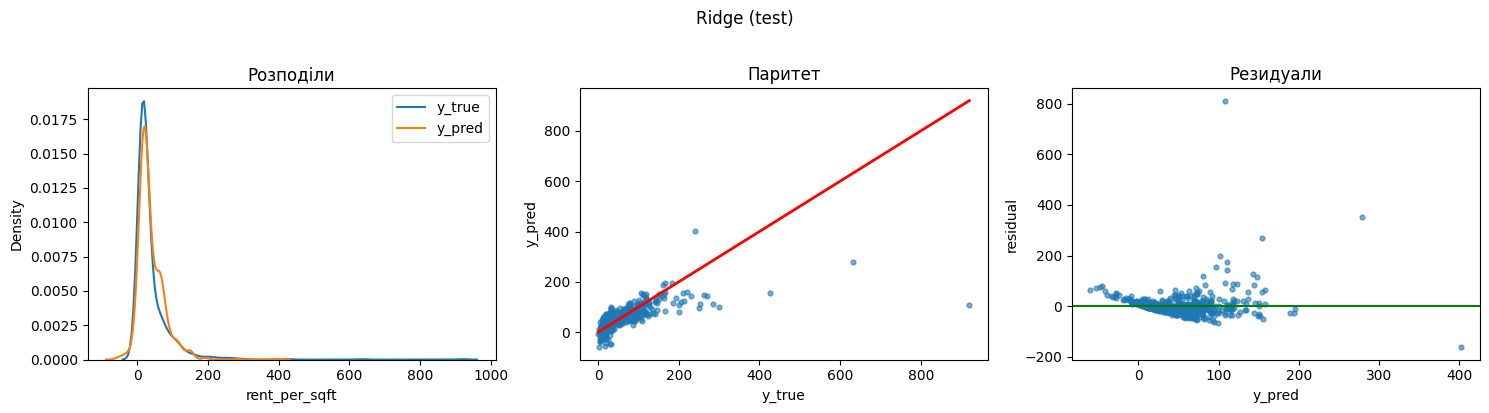

In [357]:
ridge = pipeline.Pipeline(steps=[
    ('prep', ct_std),
    ('ridge', linear_model.Ridge(random_state=42))
])

param_grid = {'ridge__alpha': [0.1, 0.3, 1.0, 3.0, 10.0]}
gs_ridge = model_selection.GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5, n_jobs=-1
)
gs_ridge.fit(X_tr, y_tr)

best_ridge = gs_ridge.best_estimator_
pred_ridge = best_ridge.predict(X_te)

print("Ridge best params:", gs_ridge.best_params_)


test_pred = test_hold.copy()
scores = []
scores.append(evaluate_model("Ridge", y_te, pred_ridge, out_df=test_pred, prefix='pred_ridge'))

plot_test_plots(y_te, pred_ridge, title='Ridge (test)')
pd.DataFrame(scores)



Модель 2 — RandomForest (з підбором гіперпараметрів)


RF best params: {'rf__max_depth': 20, 'rf__min_samples_split': 2, 'rf__n_estimators': 500}


,model,MAE,RMSE,MAPE_%,R2
0,Ridge,17.034200,38.873664,69.147653,0.500214
1,RandomForest,2.507051,23.934328,3.382122,0.810541


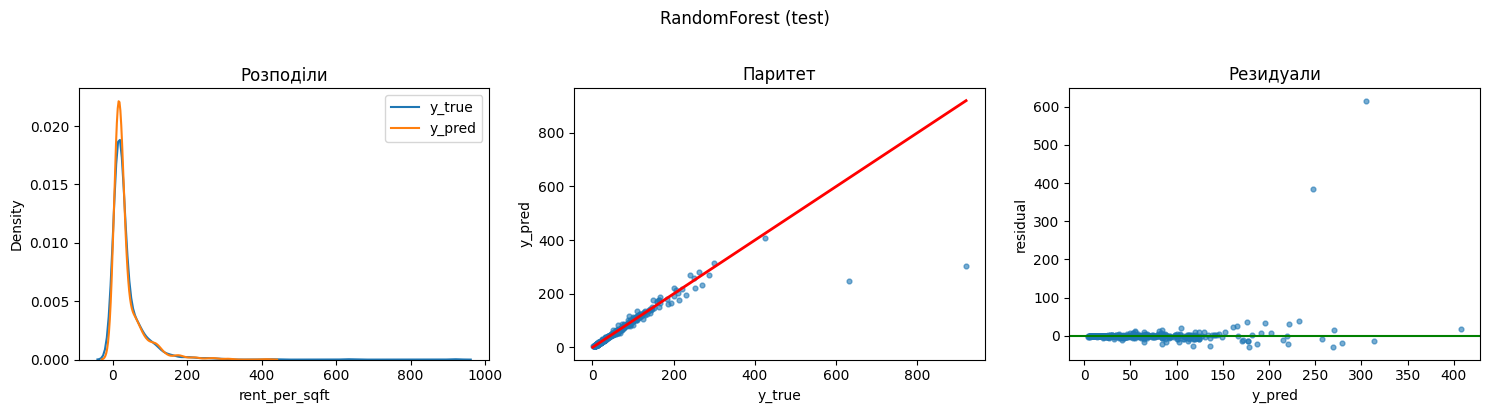

In [359]:
rf = pipeline.Pipeline(steps=[
    ('pass', 'passthrough'),
    ('rf', ensemble.RandomForestRegressor(random_state=42))
])

param_grid = {
    'rf__n_estimators': [200, 500],
    'rf__max_depth': [None, 10, 20],
    'rf__min_samples_split': [2, 5]
}
gs_rf = model_selection.GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',
    cv=5, n_jobs=-1
)
gs_rf.fit(X_tr, y_tr)

best_rf = gs_rf.best_estimator_
pred_rf = best_rf.predict(X_te)

print("RF best params:", gs_rf.best_params_)

scores.append(evaluate_model("RandomForest", y_te, pred_rf, out_df=test_pred, prefix='pred_rf'))

plot_test_plots(y_te, pred_rf, title='RandomForest (test)')
pd.DataFrame(scores)


### Частина 3.
 Аналіз результатів

Порівняння моделей

In [360]:
summary = pd.DataFrame(scores).set_index('model').round(3)
display(summary)

# Фрейм з однаковими тестовими зразками + 2 колонки прогнозів
display(test_pred.head(10))


,MAE,RMSE,MAPE_%,R2
model,,,,
Ridge,17.034,38.874,69.148,0.500
RandomForest,2.507,23.934,3.382,0.811


,rent,size,bhk,bath,floor_,max_floor,is_family,is_bachelors,contact_owner,contact_agent,...,city_Hyderabad,city_Kolkata,city_Mumbai,rent_per_sqft,pred_ridge,pred_ridge_err,pred_ridge_abs,pred_rf,pred_rf_err,pred_rf_abs
2574,70000,1800,3,3,0,4,1,1,0,1,...,0,0,0,38.888889,62.385521,-23.496632,23.496632,39.164410,-0.275521,0.275521
3602,8000,600,2,1,1,2,1,1,1,0,...,0,0,0,13.333333,20.673721,-7.340388,7.340388,13.350483,-0.017149,0.017149
1957,9500,700,2,2,2,6,1,1,1,0,...,0,0,0,13.571429,32.303744,-18.732315,18.732315,13.557048,0.014381,0.014381
429,5500,450,2,1,1,2,1,1,1,0,...,0,1,0,12.222222,23.555940,-11.333718,11.333718,12.227656,-0.005434,0.005434
465,7000,750,2,1,2,2,1,1,1,0,...,0,1,0,9.333333,8.134433,1.198900,1.198900,9.310182,0.023151,0.023151
2951,35000,1300,2,2,2,3,0,1,0,1,...,0,0,0,26.923077,47.582559,-20.659483,20.659483,26.870888,0.052189,0.052189
2784,6500,75,2,1,1,1,1,1,1,0,...,0,0,0,86.666667,78.724886,7.941780,7.941780,92.095537,-5.428870,5.428870
1126,80000,700,2,2,3,8,1,0,0,1,...,0,0,1,114.285714,90.070492,24.215222,24.215222,113.003689,1.282025,1.282025
538,28000,518,2,2,5,12,1,1,1,0,...,0,0,1,54.054054,65.981750,-11.927696,11.927696,52.074479,1.979575,1.979575
2304,12000,600,1,1,1,2,1,1,1,0,...,0,0,0,20.000000,12.015531,7.984469,7.984469,19.990138,0.009862,0.009862


Швидке порівняння на тесті

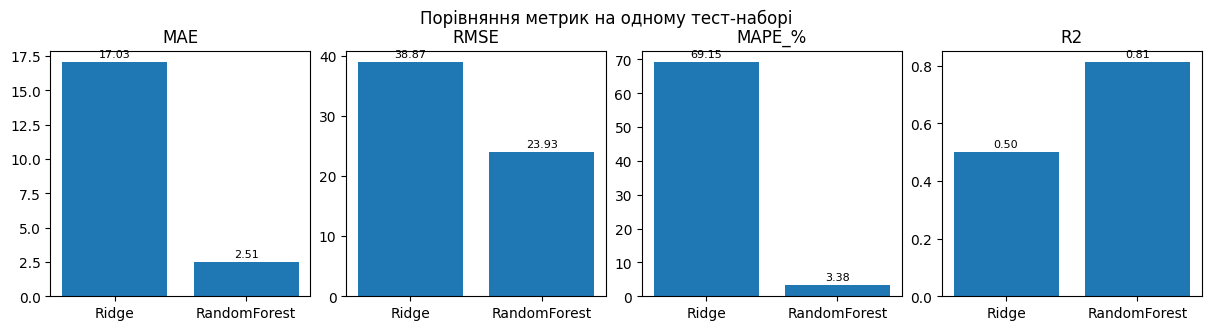

In [366]:
import matplotlib.pyplot as plt

met_cols = ['MAE','RMSE','MAPE_%','R2']
fig, axes = plt.subplots(1, 4, figsize=(12, 3), constrained_layout=True)

for ax, m in zip(axes, met_cols):
    ax.bar(summary.index, summary[m].values)
    ax.set_title(m)
    ax.set_xlabel('')
    ax.bar_label(ax.containers[0], fmt='%.2f', fontsize=8, padding=2)
plt.suptitle('Порівняння метрик на одному тест-наборі', y=1.05, fontsize=12)
plt.show()


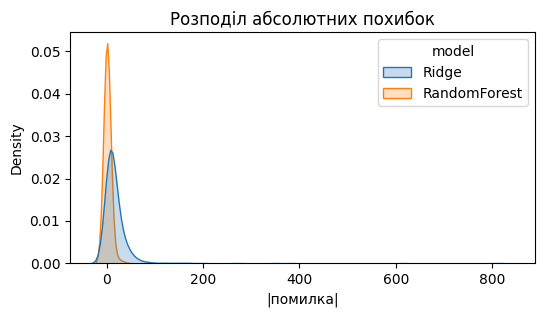

In [367]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

err_long = pd.DataFrame({
    'Ridge'       : test_pred['pred_ridge_abs'],
    'RandomForest': test_pred['pred_rf_abs'],
}).melt(var_name='model', value_name='abs_err')

plt.figure(figsize=(6,3))
sns.kdeplot(data=err_long, x='abs_err', hue='model', fill=True, common_norm=False, bw_adjust=1.2)
plt.title('Розподіл абсолютних похибок')
plt.xlabel('|помилка|')
plt.show()


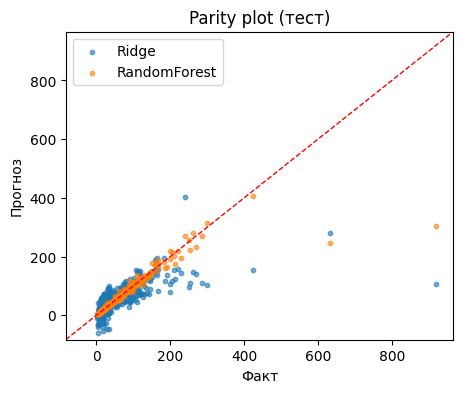

In [368]:
target_col = 'rent_per_sqft'   # якщо таргет був 'rent' — заміни тут

plt.figure(figsize=(5,4))
plt.scatter(test_pred[target_col], test_pred['pred_ridge'], s=10, alpha=0.6, label='Ridge')
plt.scatter(test_pred[target_col], test_pred['pred_rf'],    s=10, alpha=0.6, label='RandomForest')
lims = [min(plt.xlim()[0], plt.ylim()[0]), max(plt.xlim()[1], plt.ylim()[1])]
plt.plot(lims, lims, 'r--', lw=1)         # ідеальна лінія y = x
plt.xlim(lims); plt.ylim(lims)
plt.xlabel('Факт'); plt.ylabel('Прогноз'); plt.legend()
plt.title('Parity plot (тест)')
plt.show()


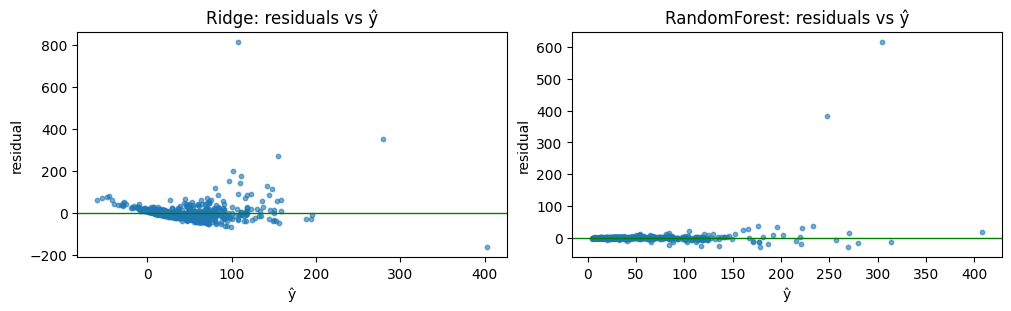

In [369]:
import numpy as np

res_df = pd.DataFrame({
    'pred_ridge': test_pred['pred_ridge'],
    'res_ridge' : test_pred[target_col] - test_pred['pred_ridge'],
    'pred_rf'   : test_pred['pred_rf'],
    'res_rf'    : test_pred[target_col] - test_pred['pred_rf'],
})

fig, axes = plt.subplots(1,2, figsize=(10,3), constrained_layout=True)
axes[0].scatter(res_df['pred_ridge'], res_df['res_ridge'], s=10, alpha=0.6)
axes[0].axhline(0, color='g', lw=1); axes[0].set_title('Ridge: residuals vs ŷ')
axes[1].scatter(res_df['pred_rf'],    res_df['res_rf'],    s=10, alpha=0.6)
axes[1].axhline(0, color='g', lw=1); axes[1].set_title('RandomForest: residuals vs ŷ')
for ax in axes: ax.set_xlabel('ŷ'); ax.set_ylabel('residual')
plt.show()


## Що показують графіки

Bar-chart метрик. Одразу видно перевагу RandomForest за MAE, RMSE, MAPE та R².

Гістограми абсолютних помилок. У RandomForest розподіл більш “гострий” біля нуля — помилок мало й вони менші; у Ridge — ширший “хвіст”.

Parity-plot (y_true vs y_pred).

Ідеальна лінія — червона y=x.

Точки RandomForest щільніше лежать уздовж цієї лінії; точки Ridge мають більший систематичний відхил.

Residuals vs y (або vs y_pred).

Для Ridge проглядається структура/тренд у залишках — ознака недоописаності (underfit) лінійною моделлю.

Для RandomForest залишки зосереджені навколо нуля без вираженого тренду — краща специфікація.

## Метричні результати (на тесті)

(значення з вашого підсумкового бар-чарту)

Ridge: MAE ≈ 17.0, RMSE ≈ 38.9, MAPE ≈ 69.1%, R² ≈ 0.50

RandomForest: MAE ≈ 2.51, RMSE ≈ 23.9, MAPE ≈ 3.38%, R² ≈ 0.81

Тлумачення:

нижчі MAE/RMSE/MAPE — краще, вищий R² — краще.

RandomForest пояснює ~81% варіації цілі (R²), тоді як Ridge — лише ~50%, і помиляється суттєво менше за всіма помилковими метриками.

## Які моделі ми порівнювали

Ridge (L2-регресія) — лінійна модель з регуляризацією. Добре працює, коли зв’язок “ознаки → ціль” близький до лінійного та коли ознаки відмасштабовані.
Підбирали гіперпараметр alpha через GridSearchCV.

RandomForestRegressor — ансамбль дерев рішень. Вміє моделювати нелінійності та перетини ознак, менш чутливий до масштабів і невеликих викидів.
Підбирали n_estimators, max_depth, min_samples_split через GridSearchCV.

## Висновок

Для цього датасету RandomForestRegressor — краща модель для прогнозування орендної ставки: має значно менші помилки (MAE/RMSE/MAPE) та суттєво вище R².

Ridge можна залишити як базову інтерпретовану модель, але для якості прогнозу на практиці варто обирати RandomForest.